In [58]:
import numpy as np 
import pandas as pd
import os
import random
from PIL import Image
import cv2
import shutil

data = "/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam"

os.listdir(data)


['planet',
 'galaxy',
 'black hole',
 'asteroid',
 'comet',
 'star',
 'constellation',
 'nebula']

In [59]:
# Identify all classes and number of samples per class
classes = []
counts = {}

for cls in os.listdir(data):
    cls_path = os.path.join(data, cls)
    if os.path.isdir(cls_path):
        classes.append(cls)
        counts[cls] = len(os.listdir(cls_path))


print("Total number of classes: ",len(classes))
print("Classes:")
print(counts)

Total number of classes:  8
Classes:
{'planet': 1472, 'galaxy': 3984, 'black hole': 656, 'asteroid': 283, 'comet': 416, 'star': 3269, 'constellation': 1552, 'nebula': 1192}


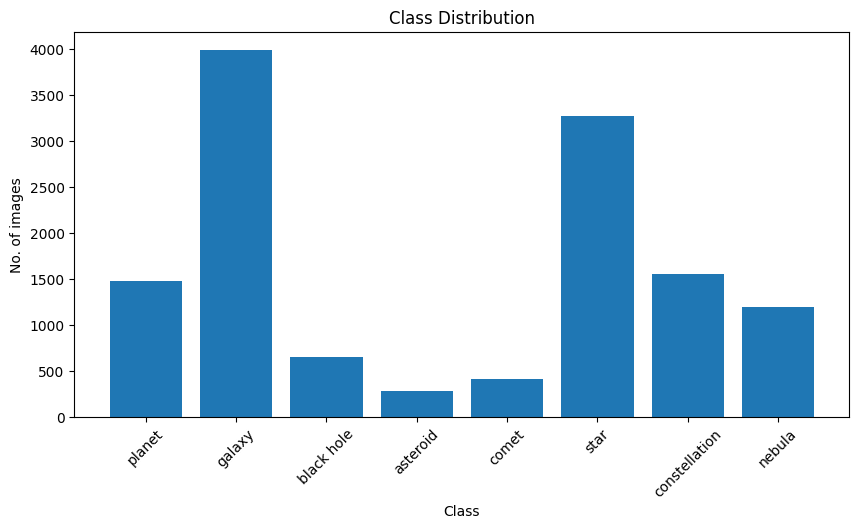

In [60]:
#Check class balance / imbalance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("No. of images")
plt.title("Class Distribution")
plt.show()


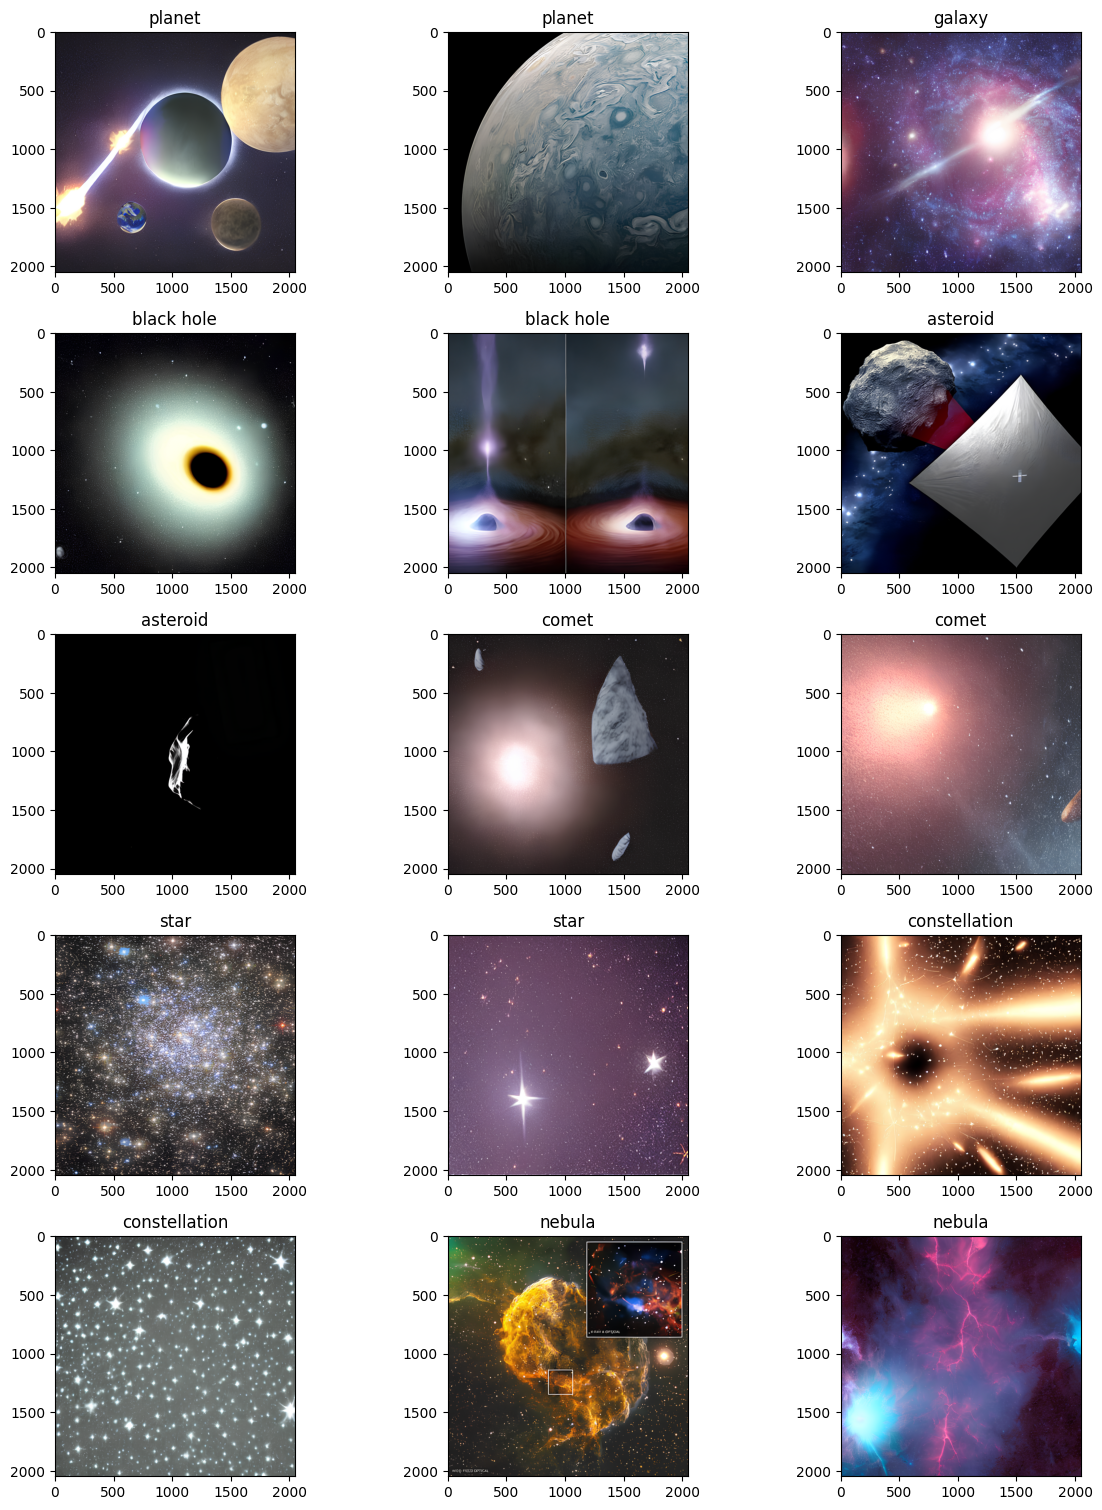

In [61]:
#checking random samples
plt.figure(figsize=(12 , len(classes)*3))
plot = 1

for class_name in classes:
    path = os.path.join(data,class_name)
    imgs = os.listdir(path)
    randomImages = random.sample(imgs , 2)

    for img in randomImages:
        imgPath = os.path.join(path , img)
        try:
            image = Image.open(imgPath)
            plt.subplot(len(classes), 3 , plot)
            plt.imshow(image)
            plt.title(class_name)
            plot = plot + 1
        except:
            pass

plt.tight_layout()
plt.show()

In [62]:
#files that are corrupt/unreadable and image format used (count)
corrupt = 0
usable_cls = {}
corrupt_cls = {}
format_count = {}
resolutions = {}

for class_name in classes:
    path = os.path.join(data, class_name)
    imgs = os.listdir(path)
    usable_cls[class_name] = 0

    for img_name in imgs:
        imgPath = os.path.join(path, img_name)
        try:
            img = Image.open(imgPath)

            # resolution
            wid, hgt = img.size
            res = f"{wid}x{hgt}"
            
            if res in resolutions:
                resolutions[res] += 1
            else:
                resolutions[res] = 1
            

            # format count
            fmt = img.format
            if fmt in format_count:
                format_count[fmt] += 1
            else:
                format_count[fmt] = 1

            usable_cls[class_name] += 1

        except:
            corrupt += 1

print("Total corrupt images:", corrupt)
for cls in classes:
    corrupt_cls[cls]=counts[cls]-usable_cls[cls]
print("Corrupt images per class: ", corrupt_cls)
print("Image formats used:", format_count)
print("Image resolutions: ",resolutions)

Total corrupt images: 1378
Corrupt images per class:  {'planet': 0, 'galaxy': 1376, 'black hole': 2, 'asteroid': 0, 'comet': 0, 'star': 0, 'constellation': 0, 'nebula': 0}
Image formats used: {'PNG': 11446}
Image resolutions:  {'2048x2048': 11446}


In [63]:
import hashlib #to use it for hashing

def file_hash(path, chunk_size=8192):  #calling data in chunks cause all at once was taking lots of time
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            md5.update(chunk)
    return md5.hexdigest()   #produces final hash for image file

hashes = {}
duplicates = []

for root,directories,files in os.walk(data):
    for file in files:

        path = os.path.join(root, file)
        try:
            h = file_hash(path)
        except:
            continue

        if h in hashes:   #checks if hash already in dict as two img with same hash will be identical
            duplicates.append((path, hashes[h]))
        else:
            hashes[h] = path

print(f"Found {len(duplicates)} duplicate pairs")


Found 1944 duplicate pairs


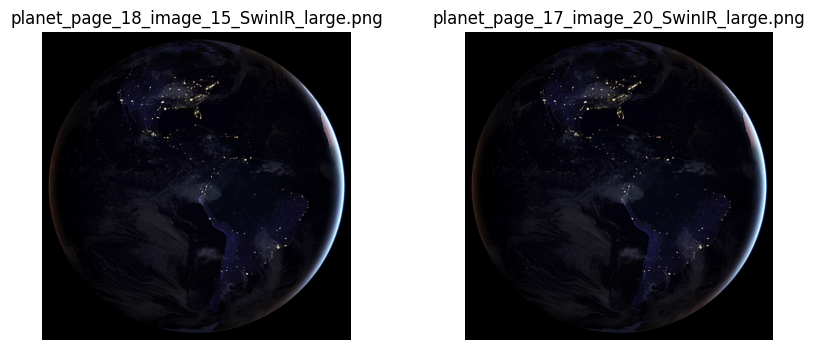

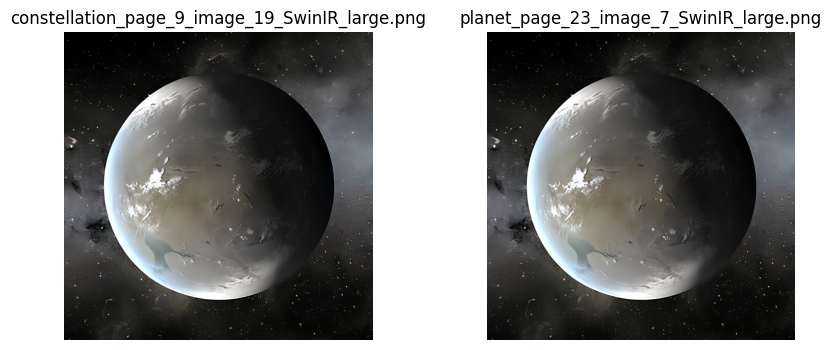

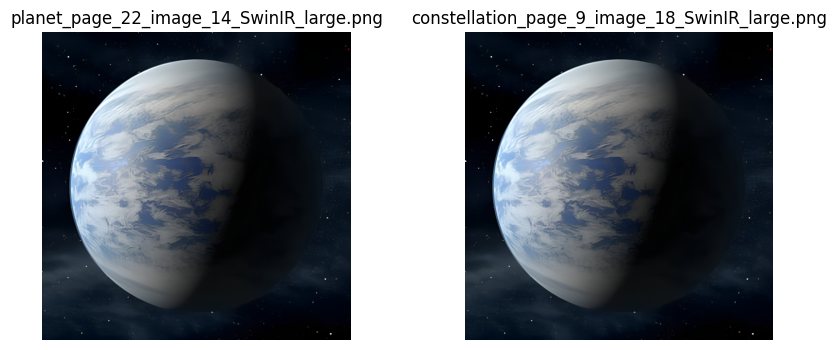

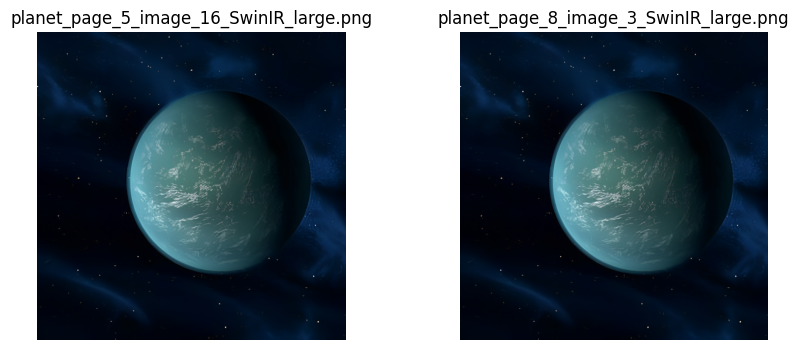

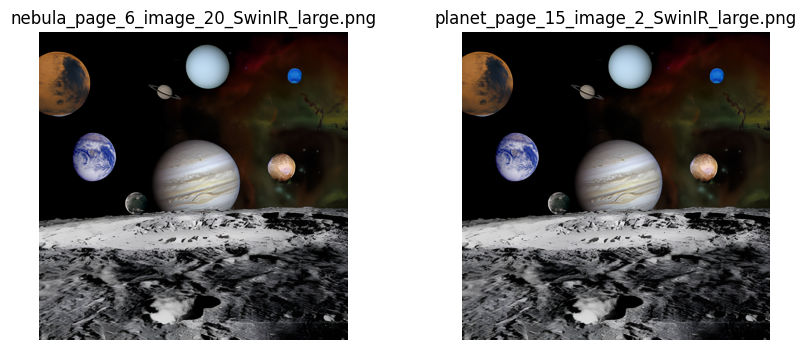

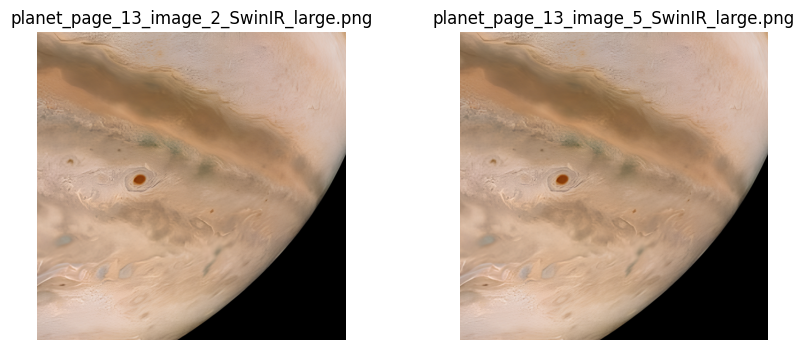

/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_9_image_2_3_SwinIR_large.png /kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_17_aug2_SwinIR_large.png
/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_3_image_6_SwinIR_large.png /kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_17_aug2_SwinIR_large.png


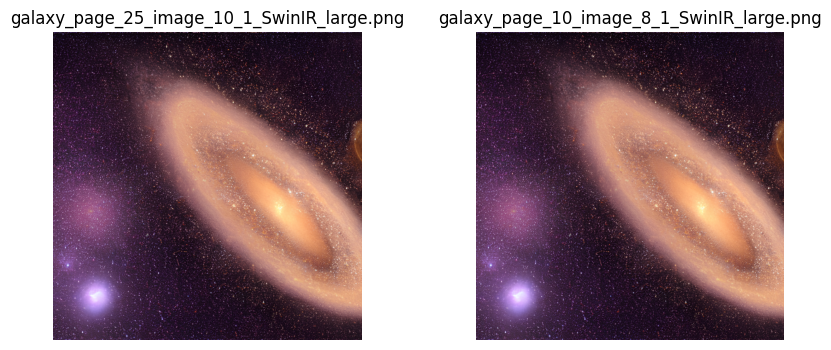

/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_3_image_8_1_SwinIR_large.png /kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_17_aug2_SwinIR_large.png
/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_9_image_9_aug3_SwinIR_large.png /kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_17_aug2_SwinIR_large.png
/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_4_image_11_4_SwinIR_large.png /kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_17_aug2_SwinIR_large.png
/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_12_1_SwinIR_large.png /kaggle/input/spacenet-an-optim

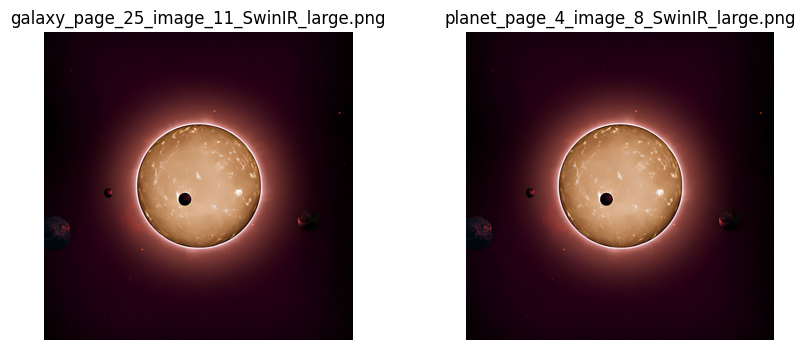

/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_2_image_14_2_SwinIR_large.png /kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_17_aug2_SwinIR_large.png


In [64]:
def show_duplicate(pair):
    img1 = cv2.imread(pair[0])
    img2 = cv2.imread(pair[1])

    if img1 is None or img2 is None:
        print(pair[0], pair[1])
        return

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(os.path.basename(pair[0]))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(os.path.basename(pair[1]))
    plt.axis("off")

    plt.show()

for pair in duplicates[:20]:  
    show_duplicate(pair)

In [65]:
def is_readable(path):
    img = cv2.imread(path)
    return img is not None
valid_pairs = []
corrupt_pairs = []

for p1, p2 in duplicates:
    r1 = is_readable(p1)
    r2 = is_readable(p2)

    if r1 and r2:
        valid_pairs.append((p1, p2))
    elif not r1 and not r2:
        corrupt_pairs.append((p1, p2))

print("Total duplicate pairs found:", len(duplicates))
print("Valid (non-corrupt) duplicate pairs:", len(valid_pairs))
print("Fully corrupt duplicate pairs:", len(corrupt_pairs))

Total duplicate pairs found: 1944
Valid (non-corrupt) duplicate pairs: 569
Fully corrupt duplicate pairs: 1375


# **Arranging folders** 

In [116]:
work_data = "/kaggle/working/spacenet_work"

train_split= 0.7
val_split= 0.15
test_split= 0.15
seed= 42

random.seed(seed)

if os.path.exists(work_data):
    shutil.rmtree(work_data)

os.makedirs(work_data)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(work_data, split), exist_ok=True)

#checking for duplicates
def file_hash(path, chunk_size=8192):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            md5.update(chunk)
    return md5.hexdigest()


def split_dataset(source_dir, output_dir):
    classes = [
        d for d in os.listdir(source_dir)
        if os.path.isdir(os.path.join(source_dir, d))
    ]

    seen_hashes = set()
    duplicate_count = 0
    corrupt_count = 0

    for class_name in classes:
        class_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_path)
        images = [img for img in images if img.lower().endswith(".png")]

        clean_images = []

        #remove corrupt+duplicates 
        for img in images:
            img_path = os.path.join(class_path, img)

            try:
                Image.open(img_path).verify()
            except:
                corrupt_count += 1
                continue

            try:
                h = file_hash(img_path)
            except:
                corrupt_count += 1
                continue

            if h in seen_hashes:
                duplicate_count += 1
                continue

            seen_hashes.add(h)
            clean_images.append(img)

        random.shuffle(clean_images)

        total=len(clean_images)
        train_limit=int(total *train_split)
        val_limit=train_end + int(total"val_split)

        train_imgs = clean_images[:train_split]
        val_imgs   = clean_images[train_end:val_split]
        test_imgs  = clean_images[val_split:]

        train_dir = os.path.join(output_dir, "train", class_name)
        val_dir   = os.path.join(output_dir, "val", class_name)
        test_dir  = os.path.join(output_dir, "test", class_name)

        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir, exist_ok=True)
        os.makedirs(test_dir, exist_ok=True)

        for img in train_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(train_dir, img)
            os.symlink(src, dst)

        for img in val_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(val_dir, img)
            os.symlink(src, dst)

        for img in test_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(test_dir, img)
            os.symlink(src, dst)

        print(f"{class_name}: {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test")

    print("\nSummary:")
    print("Duplicates removed:", duplicate_count)
    print("Corrupt images skipped:", corrupt_count)


split_dataset(data,work_data)


planet: 1026 train, 219 val, 221 test
galaxy: 1673 train, 358 val, 359 test
black hole: 440 train, 94 val, 95 test
asteroid: 197 train, 42 val, 43 test
comet: 289 train, 62 val, 63 test
star: 2210 train, 473 val, 475 test
constellation: 1007 train, 215 val, 217 test
nebula: 770 train, 165 val, 166 test

Summary:
Duplicates removed: 569
Corrupt images skipped: 1376
